# Prueba con TensorFlow

No mejora el ajuste del modelo....

Los resultados son similares a la notebook 'Main_lautaro_predict_2.ipynb'

In [167]:
# Agrego esto para realizar algunas pruebas en otro directorio pero utilizando las funciones definidas por fede...
import os
import sys

# Obtener el path de ejecucion de la notebook
current_dir = os.getcwd()

# Define el nombre del proyecto
root_dir_name = "NuestrasCaras"

# Obtiene el path del proyecto
while not os.path.basename(current_dir) == root_dir_name:
    current_dir = os.path.dirname(current_dir)
    
# Agrega path a librerias
sys.path.append(current_dir)

In [168]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import numpy as np
import os
from PIL import Image
import cv2

In [169]:
dim_imagenes = 30

In [170]:
# Configuración inicial
data_dir = os.path.join(current_dir, "output") 
nombres = []
imagenes = []

# Cargar imágenes y etiquetas
for archivo in os.listdir(data_dir):
    if archivo.endswith('.jpeg') or archivo.endswith('.jpg'):
        nombre = archivo.split('-')[0]
        ruta_imagen = os.path.join(data_dir, archivo)
        imagen = Image.open(ruta_imagen)
        imagen = np.array(imagen.resize((dim_imagenes, dim_imagenes)))  # Redimensionar imágenes para un tamaño uniforme
        if len(imagen.shape) == 3 and imagen.shape[2] == 3:
            imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises si es necesario
        imagenes.append(imagen.flatten())
        nombres.append(nombre)

imagenes_all = np.array(imagenes)
nombres_all = np.array(nombres)

In [171]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(imagenes_all, nombres_all, test_size=0.25, random_state=42, stratify=nombres_all)

In [172]:
# Aplicar PCA
pca = PCA(n_components=60)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)



In [173]:
# Escalar los datos (opcional, si ya has escalado los datos, omite este paso)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#scaler = StandardScaler()
scaler = MinMaxScaler()
X_train_pca_scaled = scaler.fit_transform(X_train_pca)
X_test_pca_scaled = scaler.transform(X_test_pca)



In [174]:
# Codificar las etiquetas
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)
y_train_categorical = to_categorical(y_train_encoded, num_classes=19)
y_test_categorical = to_categorical(y_test_encoded, num_classes=19)



In [175]:
import pandas as pd
pd.Series(nombres_all).unique().shape

(19,)

In [176]:
y_train_categorical.shape

(251, 19)

In [177]:
X_train_pca_scaled[:,3:].shape

(251, 57)

In [178]:
# Establecer la semilla para NumPy para garantizar la reproducibilidad
np.random.seed(42)

# Establecer la semilla para TensorFlow para garantizar la reproducibilidad
tf.random.set_seed(42)

In [179]:
# Definir la red neuronal

entreno_con = X_train_pca_scaled[:,3:]
testeo_con = X_test_pca_scaled[:,3:]

#model = Sequential()
#model.add(Dense(128, input_dim=entreno_con.shape[1], activation='relu'))
#model.add(Dense(64, activation='relu'))
#model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

model = Sequential()
model.add(Input(shape=entreno_con.shape[1:]))  # Definir la entrada del modelo
model.add(Dense(128, activation='sigmoid'))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(y_train_categorical.shape[1], activation='softmax'))

# Compilar el modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(entreno_con, y_train_categorical, epochs=500, batch_size=70, validation_split=0.2)

# Evaluar el modelo
loss, accuracy = model.evaluate(testeo_con, y_test_categorical)
print(f'Precisión en el conjunto de prueba: {accuracy * 100:.2f}%')

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.0489 - loss: 3.1711 - val_accuracy: 0.0196 - val_loss: 3.0618
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0282 - loss: 3.0583 - val_accuracy: 0.0196 - val_loss: 3.0080
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0618 - loss: 2.9903 - val_accuracy: 0.0000e+00 - val_loss: 2.9841
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0775 - loss: 2.9516 - val_accuracy: 0.0000e+00 - val_loss: 2.9767
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0775 - loss: 2.9308 - val_accuracy: 0.0000e+00 - val_loss: 2.9767
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0775 - loss: 2.9204 - val_accuracy: 0.0000e+00 - val_loss: 2.9799
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0800 - loss: 2.9157 - val_accuracy: 0.0784 - val_loss: 2.9842
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0943 - loss: 2.9141 - val_accuracy: 0

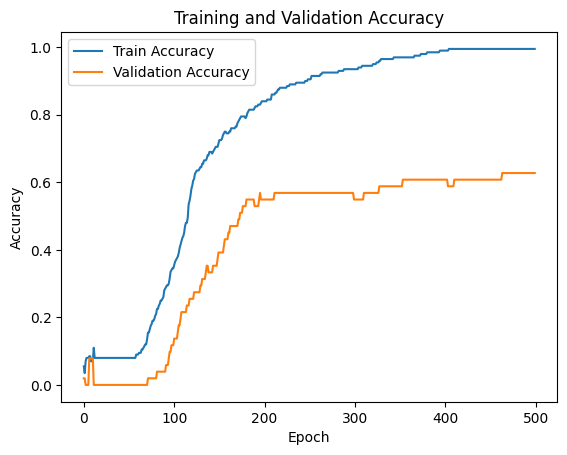

In [180]:
import matplotlib.pyplot as plt

# Obtener la precisión del entrenamiento y del conjunto de prueba del historial
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Crear un gráfico de precisión del entrenamiento y del conjunto de prueba
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [181]:
# Configuración inicial
data_dir = os.path.join(current_dir, "predict/nuevas_caras_output")  # Cambia esto a la ruta de tu directorio de imágenes
nombres = []
imagenes = []

# Cargar imágenes y etiquetas
for archivo in os.listdir(data_dir):
    if archivo.endswith('.jpeg') or archivo.endswith('.jpg'):
        nombre = archivo.split('-')[0]
        ruta_imagen = os.path.join(data_dir, archivo)
        imagen = Image.open(ruta_imagen)
        imagen = np.array(imagen.resize((dim_imagenes, dim_imagenes)))  # Redimensionar imágenes para un tamaño uniforme
        if len(imagen.shape) == 3 and imagen.shape[2] == 3:
            imagen = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises si es necesario
        imagenes.append(imagen.flatten())
        nombres.append(nombre)

new_images = np.array(imagenes)
nombres_lautaro = np.array(nombres)

In [182]:
# 2. Aplicar PCA
new_images_pca = pca.transform(new_images)
new_images_pca_scaled = scaler.transform(new_images_pca)
evaluo_con = new_images_pca_scaled[:,3:]

# 3. Hacer predicciones
predictions = model.predict(evaluo_con)

# Obtener los nombres correspondientes a las clases predichas
predicted_names = encoder.inverse_transform(np.argmax(predictions, axis=1))

# Imprimir las predicciones
for real, pred in zip(nombres_lautaro, predicted_names):
    print(f'La imagen {real} pertenece a: {pred}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
La imagen Lautaro pertenece a: Noelia
La imagen Lautaro pertenece a: Lisandro
La imagen Lautaro pertenece a: Lautaro
La imagen Lautaro pertenece a: Abel
